# Build Top and Rising Event Word Dictionaries

This notebook reads all event-word CSV files in the working directory, builds a global **top query dictionary** by counting query frequency across event files, and builds a **rising query dictionary** by aggregating frequency and search-interest statistics. Outputs are saved to `event_words/`.

In [ ]:
from pathlib import Path
import re
import pandas as pd

# Change this if your CSV files live somewhere else.
DATA_DIR = Path("event_words")
OUTPUT_DIR = Path("event_words")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_PREFIX = "searched_with_top-searches_US"
RISING_PREFIX = "searched_with_rising-searches_US"

TOP_PATTERN = f"{TOP_PREFIX}*.csv"
RISING_PATTERN = f"{RISING_PREFIX}*.csv"

In [8]:
def clean_query(s: pd.Series) -> pd.Series:
    """Normalize query strings for matching across files."""
    return (
        s.astype("string")
         .str.strip()
         .str.lower()
         .str.replace(r"\s+", " ", regex=True)
    )


def parse_increase_percent(s: pd.Series) -> pd.Series:
    """Convert strings like '4,150%' or '-8%' to numeric percentage points."""
    return pd.to_numeric(
        s.astype("string")
         .str.replace("%", "", regex=False)
         .str.replace(",", "", regex=False)
         .str.strip(),
        errors="coerce"
    )


def event_date_from_filename(path: Path) -> str:
    """Extract event date from filenames like searched_with_top-searches_US_20240801-2000_...csv."""
    m = re.search(r"US_(\d{8})-", path.name)
    if not m:
        return "unknown"
    return pd.to_datetime(m.group(1), format="%Y%m%d").date().isoformat()


def read_event_files(pattern: str, source_type: str) -> pd.DataFrame:
    """Read matching event-word CSV files with minimal verification metadata."""
    files = sorted(DATA_DIR.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f"No files matched {pattern!r} in {DATA_DIR.resolve()}"
        )

    frames = []

    for f in files:
        df = pd.read_csv(
            f,
            usecols=lambda c: c.strip().lower() in {
                "query",
                "search interest",
                "increase percent"
            }
        )

        df.columns = (
            df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ", "_")
        )

        out = pd.DataFrame({
            "event_date": event_date_from_filename(f),
            "source_file": f.name,
            "source_type": source_type,
            "query": df["query"].astype("string").str.strip(),
            "query_clean": clean_query(df["query"]),
            "search_interest": pd.to_numeric(
                df.get("search_interest"),
                errors="coerce"
            ),
        })

        if "increase_percent" in df.columns:
            out["increase_percent"] = parse_increase_percent(
                df["increase_percent"]
            )

        frames.append(out)

    out = pd.concat(frames, ignore_index=True)
    out = out.dropna(subset=["query_clean"])
    out = out[out["query_clean"].ne("")]

    return out

In [9]:
top_raw = read_event_files(TOP_PATTERN, "top")
rising_raw = read_event_files(RISING_PATTERN, "rising")

print(f"Top files: {top_raw['source_file'].nunique()}")
print(f"Top rows: {len(top_raw):,}")
print(f"Rising files: {rising_raw['source_file'].nunique()}")
print(f"Rising rows: {len(rising_raw):,}")

Top files: 72
Top rows: 3,600
Rising files: 72
Rising rows: 3,600


In [10]:
# Top dictionary: count how often each query appears across top-event files.
# Use nunique(source_file), not raw row count, so duplicate rows within one file do not inflate frequency.

top_dict = (
    top_raw
    .groupby("query_clean", as_index=False)
    .agg(
        query=("query", "first"),
        frequency=("source_file", "nunique"),
    )
    .sort_values("frequency", ascending=False)
)

top_dict.to_csv(
    OUTPUT_DIR / "top_dictionary_freq.csv",
    index=False
)

top_dict.head(20)

,query_clean,query,frequency
341,youtube,youtube,72
210,news,news,72
121,google,google,72
326,weather,weather,72
12,amazon,amazon,71
103,facebook,facebook,71
37,calculator,calculator,71
299,translate,translate,71
335,wordle,wordle,70
337,yahoo,yahoo,70


In [11]:
# Rising dictionary: aggregate event-specific rising queries.
# This preserves both frequency and search-interest / increase-percent summaries.

rising_dict = (
    rising_raw
    .groupby("query_clean", as_index=False)
    .agg(
        frequency=("query", "size"),
        query=("query", "first"),
        mean_interest=("search_interest", "mean"),
        max_interest=("search_interest", "max"),
    )
    .sort_values(
        ["frequency", "mean_interest"],
        ascending=False
    )
)

rising_dict.to_csv(OUTPUT_DIR / "rising_dictionary_agg.csv", index=False)

rising_dict.head(20)

,query_clean,frequency,query,mean_interest,max_interest
117,bitcoin price,40,bitcoin price,3.275000,8
285,dow jones,39,dow jones,8.102564,24
287,dow jones today,34,dow jones today,2.676471,8
121,blooket,29,blooket,7.448276,17
842,restaurants near me,28,restaurants near me,5.892857,9
1139,yahoo finance,26,yahoo finance,2.307692,4
1088,warriors,23,warriors,11.608696,26
366,food near me,21,food near me,9.333333,14
961,tesla stock,21,tesla stock,3.333333,8
278,dominos,20,dominos,3.800000,7


In [12]:
# Optional: thresholded dictionaries for downstream extraction.
# Adjust these cutoffs based on API budget and research design.

TOP_MIN_FREQUENCY = 3
RISING_MIN_FREQUENCY = 3

stable_top_dict = top_dict[top_dict["frequency"] >= TOP_MIN_FREQUENCY].copy()
global_rising_dict = rising_dict[rising_dict["frequency"] >= RISING_MIN_FREQUENCY].copy()

stable_top_dict.to_csv(OUTPUT_DIR / f"top_dictionary_frequency_ge{TOP_MIN_FREQUENCY}.csv", index=False)
global_rising_dict.to_csv(OUTPUT_DIR / f"rising_dictionary_frequency_ge{RISING_MIN_FREQUENCY}.csv", index=False)

print(f"Stable top terms, frequency >= {TOP_MIN_FREQUENCY}: {len(stable_top_dict):,}")
print(f"Global rising terms, frequency >= {RISING_MIN_FREQUENCY}: {len(global_rising_dict):,}")

Stable top terms, frequency >= 3: 182
Global rising terms, frequency >= 3: 440


In [13]:
top_dict.shape, rising_dict.shape

((343, 3), (1157, 5))

In [14]:
import matplotlib.pyplot as plt

PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)


def plot_frequency_histogram(
    df: pd.DataFrame,
    freq_col: str,
    title: str,
    output_name: str
):
    plot_df = df.dropna(subset=[freq_col]).copy()

    plt.figure(figsize=(8, 5))
    plt.hist(
        plot_df[freq_col],
        bins=range(
            int(plot_df[freq_col].min()),
            int(plot_df[freq_col].max()) + 2
        ),
        edgecolor="black"
    )

    plt.title(title)
    plt.xlabel("Frequency across event files")
    plt.ylabel("Number of queries")
    plt.tight_layout()

    outpath = PLOT_DIR / output_name
    plt.savefig(outpath, dpi=300)
    plt.show()

    print(f"Saved to: {outpath}")

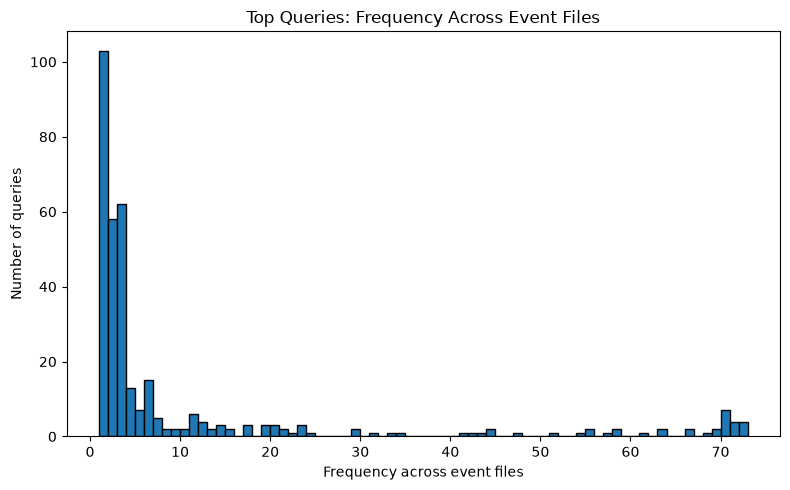

Saved to: event_words\plots\top_query_frequency_histogram.png


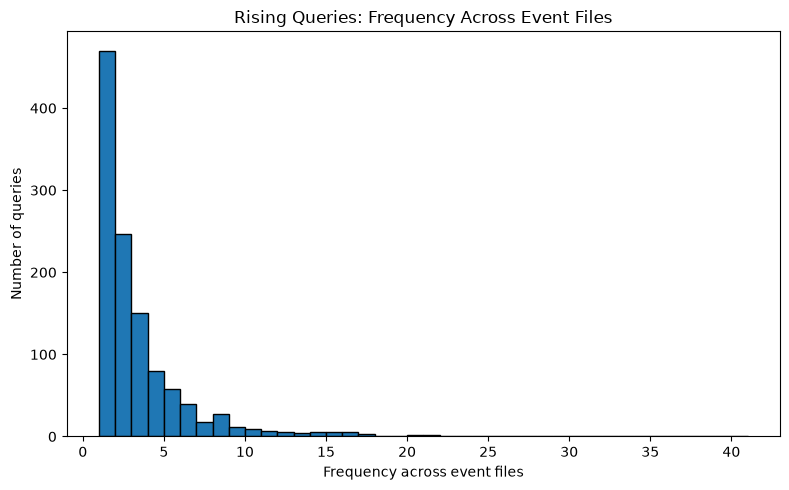

Saved to: event_words\plots\rising_query_frequency_histogram.png


In [15]:
plot_frequency_histogram(
    top_dict,
    freq_col="frequency",
    title="Top Queries: Frequency Across Event Files",
    output_name="top_query_frequency_histogram.png"
)

plot_frequency_histogram(
    rising_dict,
    freq_col="frequency",
    title="Rising Queries: Frequency Across Event Files",
    output_name="rising_query_frequency_histogram.png"
)